In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
from torch.distributions import Categorical


In [203]:
GRID_SIZE = 5
ACTION = [
    (-1,0), (0,1),
    (1,0), (0,-1),
    (0,0)
    ]
ACTION_SYMBOLS = [
    '↑', '→',
    '↓', '←',
    'O'
    ]
GOAL_STATE = (3, 2)
OBSTACLE = [
    (1,1), (1,2),
    (2,2),
    (3,1), (3,3),
    (4,1)
]


GAMMA = 0.9
ALPHA = 0.001
num_episodes = 2000
num_steps = 1000
state_dim = 25
action_dim = len(ACTION)
obstacle_through = True

In [204]:
"""
环境
"""
class GridEnv:
    def __init__(self, GRID_SIZE, GOAL_STATE, OBSTACLE, ACTION, obstacle_through=False):
        self.GRID_SIZE = GRID_SIZE
        self.GOAL_STATE = GOAL_STATE
        self.OBSTACLE = OBSTACLE
        self.ACTION = ACTION
        self.obstacle_through = obstacle_through

        self.state_dim = GRID_SIZE * GRID_SIZE
        self.current_state = None
    
    def _get_state_vector(self, state):
        """
        内部辅助函数：将二维坐标 (r, c) 转换为长度为 25 的 One-hot 一维向量
        因为 PyTorch 的神经网络需要浮点型的数组作为输入
        """
        vec = np.zeros(self.state_dim)
        r, c = state
        idx = r * self.GRID_SIZE + c
        vec[idx] = 1.0
        return vec
    
    def reset(self):
        """
        episode 重置：随机生成一个合法的起点，并返回其状态向量
        """
        while True:
            r = np.random.randint(self.GRID_SIZE)
            c = np.random.randint(self.GRID_SIZE)
            state = (r, c)
            if state == self.GOAL_STATE:
                continue
            if not self.obstacle_through and state in self.OBSTACLE:
                continue
            break

        self.current_state = state
        return self._get_state_vector(self.current_state)
    
    def step(self, action_idx):
        """
        执行动作：返回 next_state(向量形式), reward, done(是否结束)
        """
        r, c = self.current_state
        dr, dc = self.ACTION[action_idx]
        next_r, next_c = r + dr, c + dc

        done = False

        # 边界检查
        if next_r < 0 or next_r >= self.GRID_SIZE or next_c < 0 or next_c >= self.GRID_SIZE:
            reward = -1.0
            next_state = self.current_state
        
        else:
            next_state = (next_r, next_c)
            if self.obstacle_through and next_state in self.OBSTACLE:
                reward = -5.0

            elif not self.obstacle_through and next_state in self.OBSTACLE:
                reward = -5.0
                next_state = self.current_state
                
            # elif action_idx == 4: # 选择不动的动作
            #     reward = -5.0  # 惩罚不动，鼓励智能体采取行动

            elif next_state == self.GOAL_STATE:
                reward = 1.0
                done = True  # 到达终点，episode 结束
            
            else:
                reward = -0.1 # 每一步的惩罚，鼓励智能体尽快找到目标
        
        self.current_state = next_state

        return self._get_state_vector(self.current_state), reward, done


In [205]:
def extract_v_and_policy_from_a2c(trained_model, env, grid_size, device):
    V_matrix = np.zeros((grid_size, grid_size), dtype=np.float32)
    policy_matrix = np.zeros((grid_size, grid_size), dtype=int)
    
    trained_model.eval() 
    
    for r in range(grid_size):
        for c in range(grid_size):
            state = (r, c)
            
            state_vector = env._get_state_vector(state)
            state_tensor = torch.FloatTensor(state_vector).to(device)
            
            with torch.no_grad():
                action_probs = trained_model.get_action_probs(state_tensor).cpu().numpy()
                best_action = np.argmax(action_probs)
                policy_matrix[r, c] = best_action
                
                v_value = trained_model.get_v_state_value(state_tensor).cpu().item()
                V_matrix[r, c] = v_value
                
    return V_matrix, policy_matrix
"""
可视化 (Heatmap & Policy Arrows)
"""
def visualize_grid(V, policy, ALPHA_W, ALPHA_THETA, OBSTACLE, obstacle_through=False):
    plt.figure(figsize=(8, 6))
    
    V_plot = np.copy(V)
    # 只有在不允许穿透时，才把障碍物设为 NaN 挖空（显示为背景色）
    # 如果允许穿透，我们要保留它惨烈的负分，让热力图显示出来
    if not obstacle_through:
        for (r, c) in OBSTACLE:
            V_plot[r, c] = np.nan
        
    ax = sns.heatmap(V_plot, annot=True, fmt=".2f", cmap="YlGnBu", 
                     linewidths=.5, cbar_kws={'label': 'State Value $V(s)$'})
    
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            state = (i, j)
            
            if not obstacle_through and state in OBSTACLE:
                # 不可穿透的墙，画上灰色大方块
                ax.text(j + 0.5, i + 0.5, '██', ha='center', va='center', color='gray', fontsize=20)
            
            elif state == GOAL_STATE:
                # 终点
                symbol = ACTION_SYMBOLS[policy[i, j]]
                ax.text(j + 0.5, i + 0.8, f"GOAL({symbol})", ha='center', va='center', color='red', weight='bold')
            
            else:
                symbol = ACTION_SYMBOLS[policy[i, j]]
                
                # 如果允许穿透，给障碍物格子加上特殊的色和紫色箭头
                if obstacle_through and state in OBSTACLE:
                    ax.text(j + 0.5, i + 0.8, symbol, ha='center', va='center', color='purple', fontsize=18, weight='bold')
                    ax.text(j + 0.5, i + 0.5, '██', ha='center', va='center', color='red', alpha=0.3, fontsize=20)
                else:
                    # 正常平地
                    ax.text(j + 0.5, i + 0.8, symbol, ha='center', va='center', color='black', fontsize=16, weight='bold')
                
    plt.title(rf"Control ($\gamma$={GAMMA}, $\alpha_w$={ALPHA_W} $\alpha_\theta$={ALPHA_THETA}) | Obstacle Through: {obstacle_through}")
    plt.show()


def plot_learning_curve(learning_curve, window_size=100):
    """
    繪製學習曲線，包含原始回報和滑動平均回報
    """
    plt.figure(figsize=(10, 6))
    
    # 1. 繪製原始數據 (淺藍色，透明度低，用於觀察波動範圍)
    plt.plot(learning_curve, color='blue', alpha=0.2, label='Raw Total Reward')
    
    # 2. 計算並繪製滑動平均線 (紅色，較粗，用於觀察收斂趨勢)
    # 只有當 episode 數量大於窗口大小時才計算
    if len(learning_curve) >= window_size:
        # 使用 np.convolve 快速計算滑動平均
        moving_avg = np.convolve(learning_curve, np.ones(window_size)/window_size, mode='valid')
        # x 軸需要對齊，因為 valid 模式會砍掉前面的 window_size - 1 個點
        x_axis = np.arange(window_size - 1, len(learning_curve))
        plt.plot(x_axis, moving_avg, color='red', linewidth=2.5, label=f'Moving Average')
        
    plt.title('Learning Curve', fontsize=16)
    plt.xlabel('Episode', fontsize=14)
    plt.ylabel('Total Reward per Episode', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()



In [206]:
"""
经验回放池 (记忆历史旧数据和旧概率)
"""
class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = []
        self.position = 0
    
    def push(self, state, action, reward, next_state, done, old_prob):
        """记录单步数据，存下当时的 action 对应的 old_prob"""
        if len(self.buffer) < self.capacity:
            self.buffer.append(None) # 先占位，后面再覆盖
        self.buffer[self.position] = (state, action, reward, next_state, done, old_prob)
        self.position = (self.position + 1) % self.capacity
    
    def sample(self, batch_size):
        """随机抓取一把历史经验"""
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done, old_prob = map(np.stack, zip(*batch))
        return state, action, reward, next_state, done, old_prob
    
    def __len__(self):
        return len(self.buffer)
    


In [207]:
class DeepA2C(nn.Module):
    def __init__(self, grid_size=5, state_dim=2, action_dim=5, seperate_extractor=False):
        super().__init__()
        self.grid_size = grid_size
        self.seperate_extractor = seperate_extractor
        self.action_dim = action_dim
        self.state_dim = state_dim

        self.embedding = nn.Embedding(grid_size * grid_size, 64)
        # 独立 Actor 大脑
        self.actor_net = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, action_dim)
        )
        # 独立 Critic 大脑
        self.critic_net = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1) # 只输出 1 个状态价值 V(s)
        )
    
    def _get_state_idx(self, raw_s):
        
        # 无论是单条数据(25,) 还是 batch数据(batch, 25)，argmax 都能直接还原出 0-24 的正确索引
        return raw_s.argmax(dim=-1).long()

    def get_action_probs(self, raw_s):
        idx = self._get_state_idx(raw_s)
        emb = self.embedding(idx)
        return torch.softmax(self.actor_net(emb), dim=-1)
    
    def get_v_state_value(self, raw_s):
        idx = self._get_state_idx(raw_s)
        emb = self.embedding(idx)
        return self.critic_net(emb)

In [208]:
"""
off-policy A2C based on importance sampling

"""
def train_off_policy_A2C(env, model, device, num_episodes, num_steps, batch_size, capacity, GAMMA, ALPHA_W, ALPHA_THETA):
    optimizer_C = optim.Adam(list(model.critic_net.parameters()) + list(model.embedding.parameters()), lr=ALPHA_W)
    optimizer_A = optim.Adam(list(model.actor_net.parameters()) + list(model.embedding.parameters()), lr=ALPHA_THETA)

    buffer = ReplayBuffer(capacity=capacity)
    return_history = []

    for ep in range(num_episodes):
        state = env.reset()
        episode_reward = 0

        for t in range(num_steps):
            s_input = torch.tensor(state).to(device)

            with torch.no_grad():
                # 拿出当前脑子的概率分布
                probs = model.get_action_probs(s_input)
                m = Categorical(probs)
                acton = m.sample().item()
                # 记录当时的 action 对应的 old_prob
                old_prob = probs[acton].item()
            
            next_state, reward, done = env.step(acton)
            episode_reward += reward

            # 存入经验回放池
            buffer.push(state, acton, reward, next_state, done, old_prob)

            state = next_state

            if done:
                break
        
        return_history.append(episode_reward)


        # 从 Buffer 中抽样, 进行 off policy 更新
        if len(buffer) < batch_size:
            continue

        # 抽取一个 batch 的历史经验
        b_s, b_a, b_r, b_next_s, b_done, b_old_prob = buffer.sample(batch_size)

        # 转换成张量
        b_s = torch.FloatTensor(b_s).to(device)
        b_a = torch.LongTensor(b_a).to(device).unsqueeze(1)
        b_r = torch.FloatTensor(b_r).to(device).unsqueeze(1)
        b_next_s = torch.FloatTensor(b_next_s).to(device)
        b_done = torch.FloatTensor(b_done).to(device).unsqueeze(1)
        b_old_prob = torch.FloatTensor(b_old_prob).to(device).unsqueeze(1)

        # 计算重要性采样权重 rho (importance sampling ratio)
        current_probs = model.get_action_probs(b_s)
        current_probs_for_old_action = current_probs.gather(1, b_a)

        # formula: rho = pi_theta(a|s) / pi_old(a|s)
        # 必须 detach, rho仅仅作为权重, 不参与梯度更新
        rho = (current_probs_for_old_action/b_old_prob).detach()
        # rho_clipped = torch.clamp(rho, 0.8, 1.2)

        # 计算 TD Error/ Advantage
        v_current = model.get_v_state_value(b_s)
        with torch.no_grad():
            v_next = model.get_v_state_value(b_next_s)
            # 如果 done 就没有下一个状态了, 价值为 0
            td_target = b_r + GAMMA * v_next * (1 - b_done)
        
        delta = td_target - v_current

        # 联合更新 Critic 和 Actor (乘以 rho 权重)
        # Critic 更新 loss为均方误差乘以 rho 

        loss_C = 0.5 * (rho * (delta ** 2)).mean()

        # 計算目前策略的「熵 (Entropy)」
        # 數學公式: H = - \sum (p * \ln p)
        # dim=-1 表示在 5 個動作的維度上求和
        entropy = -torch.sum(current_probs * torch.log(current_probs + 1e-10), dim=-1).mean()

        log_prob = torch.log(current_probs_for_old_action + 1e-10) 
        
        # 熵正則化係數 (Beta)：通常設為 0.01 到 0.05 之間
        # ENTROPY_BETA = 0.1 
        
        # 在 Actor Loss 中減去熵（相當於在目標函數中加上熵），強迫它不要太早自信！
        # loss_A = -(rho * log_prob * delta.detach()).mean() - ENTROPY_BETA * entropy


        # Actor 更新 loss为 -log(pi_theta(a|s)) * delta * rho
        log_prob = torch.log(current_probs_for_old_action + 1e-10)
        loss_A = -(log_prob * delta.detach() * rho).mean()
        print(f"Episode {ep+1} @ Reward: {episode_reward:.8f}, Loss_C: {loss_C.item():.8f}, loss_A: {loss_A.item():.8f}, log_prob: {log_prob.mean().item():.8f}, delta: {delta.mean().item():.8f}, rho: {rho.mean().item():.8f}")

        # 反向传播更新 
        optimizer_C.zero_grad()
        loss_C.backward()
        optimizer_C.step()

        optimizer_A.zero_grad()
        loss_A.backward()
        optimizer_A.step()

        if (ep+1) % 10 == 0:
            # print(f"Episode {ep+1}/{num_episodes}, Reward: {episode_reward:.2f}, Loss_C: {loss_C.item():.4f}, Loss_A: {loss_A.item():.4f}")
            print(f"Episode {ep+1}/{num_episodes}")
    return model, return_history


In [209]:
env_A2C = GridEnv(GRID_SIZE, GOAL_STATE, OBSTACLE, ACTION, obstacle_through)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_A2C = DeepA2C(grid_size=GRID_SIZE, state_dim=state_dim, action_dim=action_dim).to('cpu')

In [210]:
trained_model_off, return_history_off = train_off_policy_A2C(
    env_A2C, model_A2C, device, 
    num_episodes=2000, num_steps=1000, batch_size=64, capacity=10000,
    GAMMA=0.99, ALPHA_W=0.001, ALPHA_THETA=0.0003
)
torch.save(trained_model_off.state_dict(), "a2c_maze_weights_off_policy.pth")
print("🎉 模型权重已成功保存为 a2c_maze_weights.pth!")

Episode 1 @ Reward: -60.90000000, Loss_C: 1.68721104, loss_A: -1.47202325, log_prob: -1.59219003, delta: -0.94178897, rho: 1.00000000
Episode 2 @ Reward: -50.00000000, Loss_C: 2.05697823, loss_A: -1.76073480, log_prob: -1.58888507, delta: -1.10115480, rho: 0.99829602
Episode 3 @ Reward: -36.70000000, Loss_C: 1.08818960, loss_A: -1.00185156, log_prob: -1.58001351, delta: -0.63428944, rho: 0.99870461
Episode 4 @ Reward: -62.20000000, Loss_C: 1.46085751, loss_A: -1.34314060, log_prob: -1.60085392, delta: -0.84133834, rho: 0.99748552
Episode 5 @ Reward: -22.90000000, Loss_C: 0.49768335, loss_A: -0.72004336, log_prob: -1.59146905, delta: -0.45837754, rho: 1.00019372
Episode 6 @ Reward: -188.40000000, Loss_C: 1.63735580, loss_A: -1.43239057, log_prob: -1.60325670, delta: -0.89592719, rho: 0.99832290
Episode 7 @ Reward: -119.60000000, Loss_C: 1.61419225, loss_A: -1.32650244, log_prob: -1.58874333, delta: -0.84311718, rho: 0.99746674
Episode 8 @ Reward: -109.90000000, Loss_C: 1.06571579, loss_

In [211]:
model_trained_A2C = DeepA2C(grid_size=GRID_SIZE, state_dim=2, action_dim=action_dim, seperate_extractor=True).to(device)
weights_dict = torch.load("a2c_maze_weights_off_policy.pth", map_location=device)
model_trained_A2C.load_state_dict(weights_dict)
v_A2C, policy_a2c = extract_v_and_policy_from_a2c(model_trained_A2C, env_A2C, GRID_SIZE, device)

C:\Users\Dieu\AppData\Local\Temp\ipykernel_21636\1343012378.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights_dict = torch.load("a2c_maze_weights_off_policy.pth", 

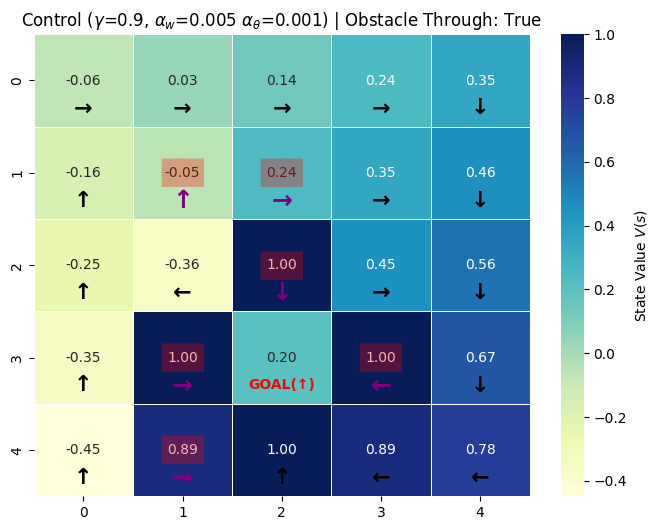

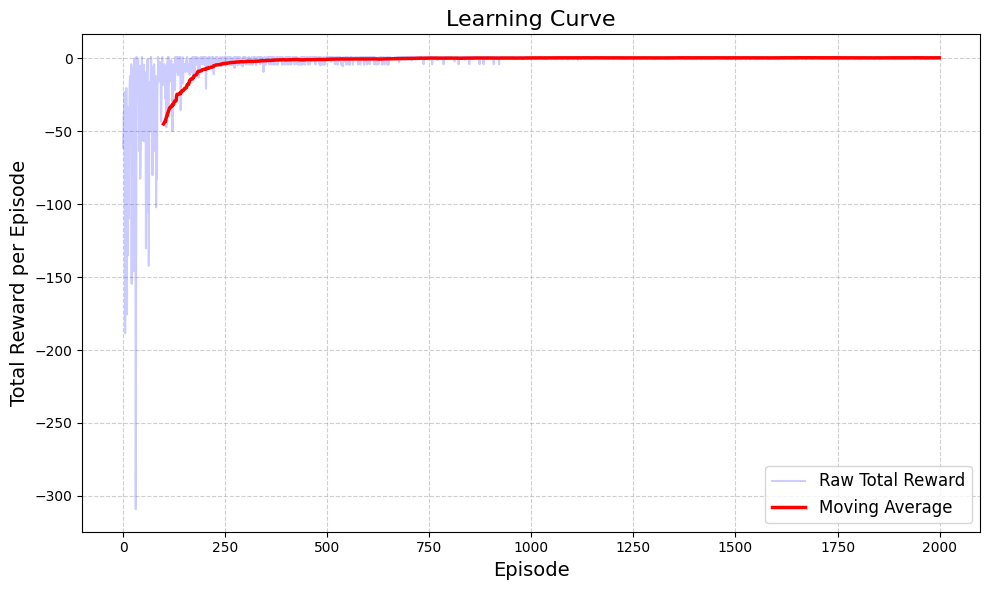

In [212]:
visualize_grid(v_A2C, policy_a2c, ALPHA_W=0.005, ALPHA_THETA=0.001, OBSTACLE=OBSTACLE, obstacle_through=obstacle_through)
plot_learning_curve(return_history_off, window_size=100)